# Домшанее задание 5. HMM

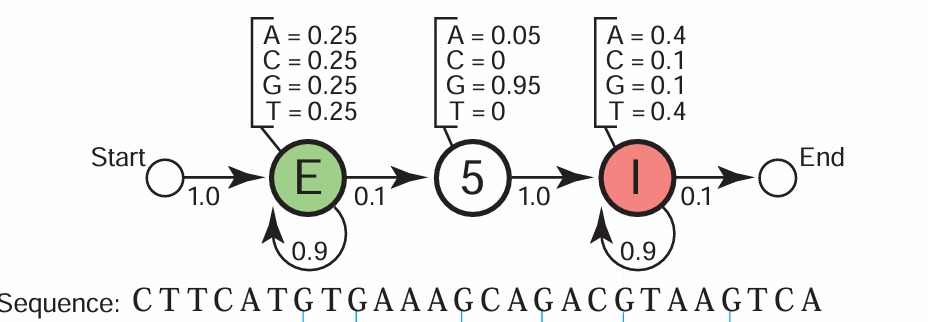

In [109]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [116]:
s = ["E", "5", "I"]
s_i = {s: i for i, s in enumerate(s)}
e = ["A", "C", "G", "T"]
e_i = {e: i for i, e in enumerate(e)}

O = list("CTTCATGTGAAAGCAGACGTAAGTCA") #наблюдения - последовательность
O_i = [e_i[o] for o in O]
T = len(O)

In [14]:
O_i

[1, 3, 3, 1, 0, 3, 2, 3, 2, 0, 0, 0, 2, 1, 0, 2, 0, 1, 2, 3, 0, 0, 2, 3, 1, 0]

Матрицы переходов и эмиссий

In [4]:
A = np.array([
    [0.9, 0.1, 0.0],  # E
    [0.0, 0.0, 1.0],  # 5
    [0.0, 0.0, 0.9],  # I
])

#конец последовательности
X = np.array([
    0.0,
    0.0,
    0.1
])

B = np.array([
    [0.25, 0.25, 0.25, 0.25],  # E
    [0.05, 0.0, 0.95, 0.0],    # 5
    [0.4, 0.1, 0.1, 0.4],      # I
])

Начальный вектор вероятностей

In [5]:
pi = np.array([1.0, 0.0, 0.0])

Переведем все матрицы в логарифмическую шкалу

In [7]:
logA = np.log(A + 1e-100)
logB = np.log(B + 1e-100)
logpi = np.log(pi + 1e-100)
logx = np.log(X + 1e-100)

## Алгоритм Витерби

In [73]:
delta = [[-np.inf for i in range(T)] for j in range(len(s))]
psi = [[0 for i in range(T)] for j in range(len(s))]

In [74]:
for j in range(len(s)):
    delta[j][0] = logpi[j] + logB[j][O_i[0]] #t=0

for t in range(1, T):
    for j in range(len(s)):
        scores = [delta[i][t-1] + logA[i][j] for i in range(len(s))]
        psi[j][t] = np.argmax(scores)
        b_j = logB[j][O_i[t]]
        delta[j][t] = np.max(scores) + b_j

In [77]:
final = [delta[j][T-1] + logx[j] for j in range(len(s))] #это плюс выход из цепи
s_T = np.argmax(final) #конечное состояние
P = final[s_T]

path_i = [0] * T
path_i[T-1] = s_T
for t in range(T-2, -1, -1):
    path_i[t] = psi[path_i[t+1]][t+1]

path = [s[i] for i in path_i]

**Лог-вероятность:**

In [82]:
P

np.float64(-41.21967768602254)

**Последовательность:**

In [78]:
print(*path)

E E E E E E E E E E E E E E E E E E 5 I I I I I I I


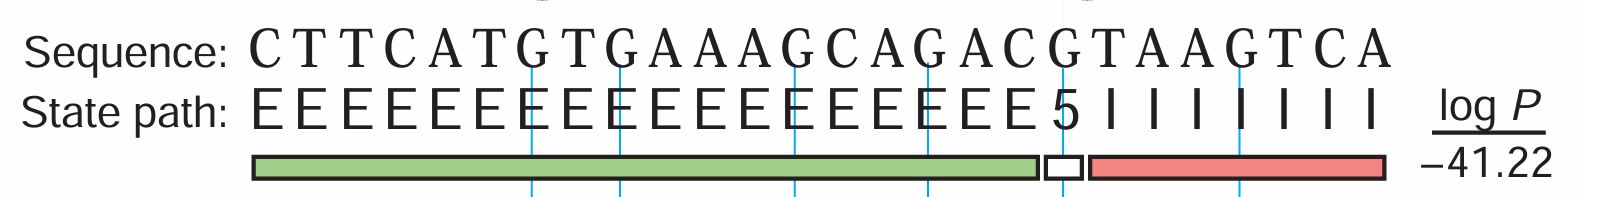

**Полученная последовательность скрытых состояний совпадает с приведенной в оригинальной статье**

## Алгоритм Forward

In [90]:
def log_sum_exp(arr):
    m = np.max(arr)
    return m + np.log(np.sum(np.exp(arr - m)))

In [93]:
alpha = [[-np.inf for i in range(T)] for j in range(len(s))]

for j in range(len(s)):
    alpha[j][0] = logpi[j] + logB[j][O_i[0]] #t=0

for t in range(1, T):
    for j in range(len(s)):
        scores = [alpha[i][t-1] + logA[i][j] for i in range(len(s))]
        b_j = logB[j][O_i[t]]
        alpha[j][t] = log_sum_exp(scores) + b_j

log_p = log_sum_exp([alpha[j][T-1] + logx[j] for j in range(len(s))])
p = np.exp(log_p)

In [94]:
print("Лог-вероятность", log_p)
print("Вроятность:", p)

Лог-вероятность -40.44742615843331
Вроятность: 2.715851454514808e-18


## Алгоритм Backward

In [99]:
beta = [[-np.inf for _ in range(T)] for _ in range(len(s))]

for j in range(len(s)):
    beta[j][T-1] = logx[j] #сразу учтем вероятность выхода из цепи

for t in range(T-2, -1, -1):
    for i in range(len(s)):
        scores = [logA[i][j] + logB[j][O_i[t+1]] + beta[j][t+1] for j in range(len(s))]
        beta[i][t] = log_sum_exp(scores)

log_p = log_sum_exp([logpi[j] + logB[j][O_i[0]] + beta[j][0]for j in range(len(s))])

print("Лог-вероятность (backward)::", log_p)

Лог-вероятность (backward):: -40.447426158433295


*(это проверка реализации - вероятность forward и backward совпадают)*

## Апостериорное декодирование (Forward-Backward)

In [110]:
gamma = [[0.0 for i in range(T)] for j in range(len(s))]

for t in range(T):
    for i in range(len(s)):
        log_gamma = alpha[i][t] + beta[i][t] - log_p
        gamma[i][t] = np.exp(log_gamma)

In [112]:
for i in range(len(s)):
    max_val = max(gamma[i])
    max_t = gamma[i].index(max_val)
    print(f"s={s[i]}: максимум при t={max_t+1}, значение={max_val}")

s=E: максимум при t=1, значение=1.0
s=5: максимум при t=19, значение=0.4619717543272295
s=I: максимум при t=24, значение=0.9999999999999858


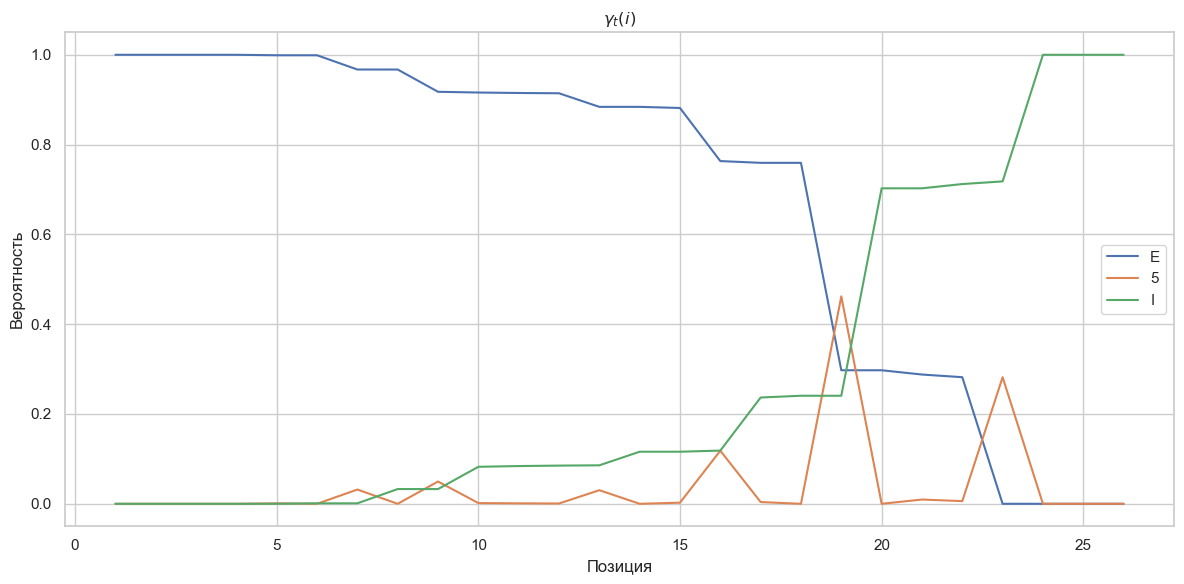

In [115]:
t_values = list(range(1, T+1))

plt.figure(figsize=(12, 6))

plt.plot(t_values, gamma[0], label="E")
plt.plot(t_values, gamma[1], label="5")
plt.plot(t_values, gamma[2], label="I")

plt.title(r"$\gamma_t(i)$")
plt.xlabel("Позиция")
plt.ylabel("Вероятность")

plt.legend()
plt.tight_layout()

plt.show()